> **UFH DIRISA 2026 — Submission Notebook 3/6**  
> Project: *Eastern Cape Municipal Electoral Dynamics*  
> Scope: Eastern Cape Local Government Elections, 2000–2021 historical evidence with model-based 2026 scenarios.  
> Reproducibility rule: run notebooks in numerical order from the repository root.


# Phase 3 — Master Analytical Panel & Exploratory Data Analysis

## Eastern Cape Municipal Electoral Dynamics

This notebook integrates the completed election and demographic phases into the project's **master analytical panel** and performs the main exploratory analysis.

### Phase 3 objectives

1. Merge Phase 1 election outcomes, competition measures and selected party shares.
2. Merge Phase 2 temporally aligned demographic features.
3. Validate the municipality × election-year panel.
4. Analyse voter turnout across election years and municipalities.
5. Examine descriptive associations between turnout, political competition and demographics.
6. Produce reusable tables and figures for modelling, the dashboard and presentation.
7. Create a **leakage-safe modelling view** for Phase 4.

### Interpretation rule

All relationships in this notebook are **descriptive associations**. Municipality-level correlations do not establish individual voter behaviour or causality.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("Run this notebook from inside the DIRISA project.")

PROJECT_ROOT = find_project_root()

PHASE1_DIR = PROJECT_ROOT / "data" / "processed" / "elections" / "phase1"
PHASE2_DIR = PROJECT_ROOT / "data" / "processed" / "demographics" / "phase2"
PANEL_DIR = PROJECT_ROOT / "data" / "processed" / "panels" / "phase3"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "phase3"

PANEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ELECTION_FILE = PHASE1_DIR / "municipality_election_panel_2000_2021.csv"
PARTY_FILE = PHASE1_DIR / "party_shares_selected_wide_2000_2021.csv"

# Support both the original Phase 2 filename and the consolidated Phase 2 filename.
DEMOGRAPHIC_CANDIDATES = [
    PHASE2_DIR / "demographics_historical_aligned_2000_2021.csv",
    PHASE2_DIR / "demographics_aligned_to_elections_2000_2021.csv",
]
DEMOGRAPHIC_FILE = next((p for p in DEMOGRAPHIC_CANDIDATES if p.exists()), None)

print("Project root:", PROJECT_ROOT)
print("Phase 1 election file:", ELECTION_FILE.exists())
print("Phase 1 party file:", PARTY_FILE.exists())
print("Phase 2 demographic file:", DEMOGRAPHIC_FILE)

if not ELECTION_FILE.exists():
    raise FileNotFoundError(f"Missing Phase 1 output: {ELECTION_FILE}")
if not PARTY_FILE.exists():
    raise FileNotFoundError(f"Missing Phase 1 output: {PARTY_FILE}")
if DEMOGRAPHIC_FILE is None:
    raise FileNotFoundError(
        "Missing Phase 2 historical demographic output. Run Phase 2 first."
    )


Project root: C:\Users\Monwabisi05\IdeaProjects\Dirisa_TeamQualification
Phase 1 election file: True
Phase 1 party file: True
Phase 2 demographic file: C:\Users\Monwabisi05\IdeaProjects\Dirisa_TeamQualification\data\processed\demographics\phase2\demographics_historical_aligned_2000_2021.csv


## 1. Load authoritative Phase 1 and Phase 2 outputs

Unlike the earlier exploratory teammate notebook, Phase 3 does **not** concatenate the old `clean_res11`, `clean_res16` and `clean_res21` files. It starts from the validated Phase 1 municipality-election panel and Phase 2 demographic output.


In [2]:
elections = pd.read_csv(ELECTION_FILE)
party = pd.read_csv(PARTY_FILE)
demographics = pd.read_csv(DEMOGRAPHIC_FILE)

print("Election panel:", elections.shape)
print("Selected party shares:", party.shape)
print("Demographics:", demographics.shape)

display(elections.head())
display(demographics.head())


Election panel: (164, 20)
Selected party shares: (164, 7)
Demographics: (165, 14)


,MuniCode,RegisteredVoters,SpoiltVotes,VotingDistricts,ValidVotes,VotesCast,Turnout_%,Year,TopShare_%,Margin_pts,ENP,NumberOfParties,PreviousRegisteredVoters,PreviousTurnout_%,PreviousENP,PreviousMargin_pts,PreviousTopShare_%,TurnoutChange_pts,ENPChange,MarginChange_pts
0,BUF,341665,4073,216,194108,198181,58.004478,2000,81.267130,68.015229,1.472733,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BUF,358460,2761,298,184573,187334,52.260782,2006,81.334215,69.401808,1.477063,9,341665.0,58.004478,1.472733,68.015229,81.267130,-5.743696,0.004330,1.386580
2,BUF,384910,4016,308,212540,216556,56.261464,2011,69.125341,48.864684,1.916003,8,358460.0,52.260782,1.477063,69.401808,81.334215,4.000681,0.438940,-20.537124
3,BUF,419044,5843,339,227772,233615,55.749516,2016,59.864250,36.412729,2.369499,12,384910.0,56.261464,1.916003,48.864684,69.125341,-0.511948,0.453495,-12.451956
4,BUF,406486,3571,351,180265,183836,45.225666,2021,60.510914,41.017946,2.381045,26,419044.0,55.749516,2.369499,36.412729,59.864250,-10.523850,0.011547,4.605217


,MuniCode,Year,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,DemographicStatus,DemographicMethod
0,BUF,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...
1,BUF,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...
2,BUF,2011,781853.0,26.500000,6.100000,27.000000,5.100000,27.100000,13.200000,71.900000,69.100000,81.100000,Observed,Census 2011 municipality value
3,BUF,2016,869763.0,25.727273,6.872727,28.363636,4.645455,30.054545,14.018182,78.127273,75.736364,87.236364,Interpolated,Linear interpolation between Census 2011 and C...
4,BUF,2021,957673.0,24.954545,7.645455,29.727273,4.190909,33.009091,14.836364,84.354545,82.372727,93.372727,Interpolated,Linear interpolation between Census 2011 and C...


## 2. Build the master analytical panel

In [3]:
# Validate join keys before merging.
for name, frame in {
    "elections": elections,
    "party": party,
    "demographics": demographics,
}.items():
    assert {"MuniCode", "Year"}.issubset(frame.columns)
    assert not frame.duplicated(["MuniCode", "Year"]).any(), (
        f"Duplicate MuniCode-Year keys in {name}"
    )

master = elections.merge(
    party,
    on=["MuniCode", "Year"],
    how="left",
    validate="one_to_one",
)

master = master.merge(
    demographics,
    on=["MuniCode", "Year"],
    how="left",
    validate="one_to_one",
)

master = master.sort_values(["Year", "MuniCode"]).reset_index(drop=True)

print("Master panel shape:", master.shape)
display(master.head())


Master panel shape: (164, 37)


,MuniCode,RegisteredVoters,SpoiltVotes,VotingDistricts,ValidVotes,VotesCast,Turnout_%,Year,TopShare_%,Margin_pts,ENP,NumberOfParties,PreviousRegisteredVoters,PreviousTurnout_%,PreviousENP,PreviousMargin_pts,PreviousTopShare_%,TurnoutChange_pts,ENPChange,MarginChange_pts,ANC,DA,EFF,UDM,ATM,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,DemographicStatus,DemographicMethod
0,BUF,341665,4073,216,194108,198181,58.004478,2000,81.267130,68.015229,1.472733,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.267130,13.251901,0.0,1.509984,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...
1,EC101,28769,422,28,17328,17750,61.698356,2000,55.459372,22.212604,2.355619,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.459372,33.246768,0.0,5.257387,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...
2,EC102,15808,148,17,8500,8648,54.706478,2000,70.341176,43.623529,1.763555,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.341176,26.717647,0.0,2.941176,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...
3,EC104,39034,351,27,22157,22508,57.662551,2000,82.019226,67.779934,1.441564,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82.019226,14.239292,0.0,1.886537,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...
4,EC105,26668,253,20,16617,16870,63.259337,2000,75.561172,54.618764,1.624901,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.561172,20.942408,0.0,1.618824,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unavailable_pre2011,No municipality-level snapshot available; no b...


## 3. Master-panel quality control

Expected election rows:

- 2000: 32 municipalities
- 2006: 33
- 2011: 33
- 2016: 33
- 2021: 33
- Total: **164 municipality-election observations**

The 2000 difference is inherited from Phase 1's harmonised analytical geography. Historical demographic variables should be available for 2011 onward and intentionally unavailable before 2011.


In [4]:
year_counts = master.groupby("Year").size()
expected_counts = {2000: 32, 2006: 33, 2011: 33, 2016: 33, 2021: 33}

qc_rows = [
    ["Master rows", len(master), 164],
    ["Duplicate MuniCode-Year keys", master.duplicated(["MuniCode", "Year"]).sum(), 0],
    ["Missing party-share joins", master[["ANC", "DA", "EFF", "UDM", "ATM"]].isna().all(axis=1).sum(), 0],
    ["Invalid turnout rows", ((master["Turnout_%"] < 0) | (master["Turnout_%"] > 100)).sum(), 0],
    ["Invalid ENP rows", (master["ENP"] < 1).sum(), 0],
    ["Negative margin rows", (master["Margin_pts"] < 0).sum(), 0],
]

for year, expected in expected_counts.items():
    qc_rows.append([
        f"{year} rows",
        int(year_counts.get(year, 0)),
        expected
    ])

post2011 = master[master["Year"] >= 2011]
pre2011 = master[master["Year"] < 2011]
demo_cols = ["Pop", "U15", "O65", "Med", "NoSch", "Matric", "Higher", "Formal", "Water", "Elec"]

qc_rows += [
    ["2011+ rows with complete demographics", post2011[demo_cols].notna().all(axis=1).sum(), 99],
    ["Pre-2011 rows with demographics intentionally unavailable", pre2011[demo_cols].isna().all(axis=1).sum(), 65],
]

qc = pd.DataFrame(qc_rows, columns=["Check", "Actual", "Expected"])
qc["Pass"] = qc["Actual"] == qc["Expected"]

display(qc)
assert qc["Pass"].all(), "Phase 3 QC gate failed."
print("PASS: master analytical panel validated.")


,Check,Actual,Expected,Pass
0,Master rows,164,164,True
1,Duplicate MuniCode-Year keys,0,0,True
2,Missing party-share joins,0,0,True
3,Invalid turnout rows,0,0,True
4,Invalid ENP rows,0,0,True
5,Negative margin rows,0,0,True
6,2000 rows,32,32,True
7,2006 rows,33,33,True
8,2011 rows,33,33,True
9,2016 rows,33,33,True


PASS: master analytical panel validated.


## 4. Turnout descriptive statistics

Two summaries are useful:

- **Municipality mean turnout**: every municipality receives equal weight.
- **Registered-voter-weighted turnout**: total votes cast divided by total registered voters for the municipalities in that election year.

The second measure better represents aggregate participation across the panel, while the first describes the typical municipality.


In [5]:
turnout_summary = (
    master.groupby("Year")["Turnout_%"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

weighted = (
    master.groupby("Year")[["VotesCast", "RegisteredVoters"]]
    .sum()
    .reset_index()
)
weighted["WeightedTurnout_%"] = (
    100 * weighted["VotesCast"] / weighted["RegisteredVoters"]
)

turnout_summary = turnout_summary.merge(
    weighted[["Year", "WeightedTurnout_%"]],
    on="Year",
    how="left",
)

turnout_summary = turnout_summary.rename(columns={
    "count": "Municipalities",
    "mean": "MeanTurnout_%",
    "median": "MedianTurnout_%",
    "std": "SDTurnout_%",
    "min": "MinTurnout_%",
    "max": "MaxTurnout_%",
})

display(turnout_summary.round(2))


,Year,Municipalities,MeanTurnout_%,MedianTurnout_%,SDTurnout_%,MinTurnout_%,MaxTurnout_%,WeightedTurnout_%
0,2000,32,56.30,57.58,5.15,43.05,66.83,56.16
1,2006,33,57.19,57.57,3.45,49.66,63.71,56.33
2,2011,33,58.03,56.92,4.71,46.68,68.27,57.86
3,2016,33,56.23,55.96,4.35,45.11,66.11,56.17
4,2021,33,48.03,47.20,3.96,39.42,57.01,46.36


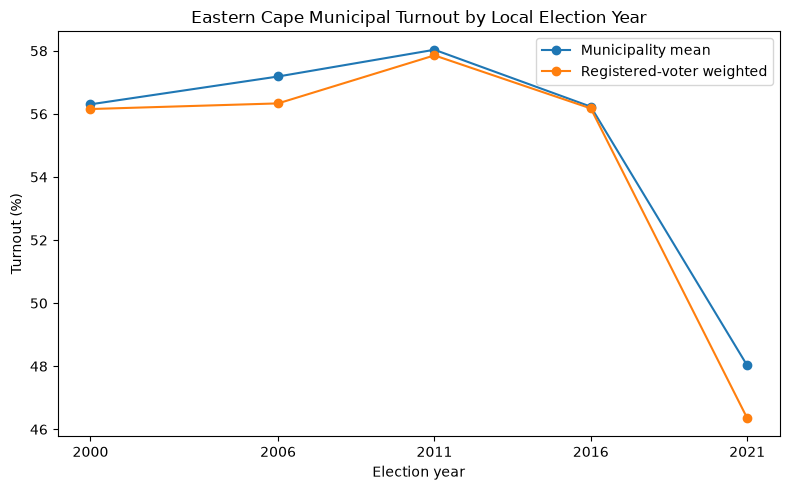

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(turnout_summary["Year"], turnout_summary["MeanTurnout_%"], marker="o", label="Municipality mean")
ax.plot(turnout_summary["Year"], turnout_summary["WeightedTurnout_%"], marker="o", label="Registered-voter weighted")
ax.set_title("Eastern Cape Municipal Turnout by Local Election Year")
ax.set_xlabel("Election year")
ax.set_ylabel("Turnout (%)")
ax.set_xticks(turnout_summary["Year"])
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "turnout_by_year.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Municipality-level turnout change

In [7]:
turnout_pivot = master.pivot(
    index="MuniCode",
    columns="Year",
    values="Turnout_%"
)

# Focus the teammate's original comparison on the fully harmonised 2011–2021 period.
turnout_pivot["Change_2011_2021_pts"] = turnout_pivot[2021] - turnout_pivot[2011]
turnout_change = (
    turnout_pivot[[2011, 2016, 2021, "Change_2011_2021_pts"]]
    .dropna()
    .sort_values("Change_2011_2021_pts")
    .reset_index()
)

display(turnout_change)


Year,MuniCode,2011,2016,2021,Change_2011_2021_pts
0,NMA,64.682248,63.533683,45.784114,-18.898135
1,EC106,64.685011,57.687991,46.376927,-18.308084
2,EC101,62.354111,61.310441,46.864430,-15.489681
3,EC145,61.917730,57.357882,47.247300,-14.670431
4,EC142,59.336590,57.767298,46.408693,-12.927897
5,EC104,55.798199,52.586318,42.925522,-12.872677
6,EC135,60.437428,57.879340,48.070521,-12.366907
7,EC122,54.576904,51.188240,42.301753,-12.275151
8,EC105,67.149268,65.232912,55.534472,-11.614797
9,EC155,53.909760,50.669424,42.305778,-11.603982


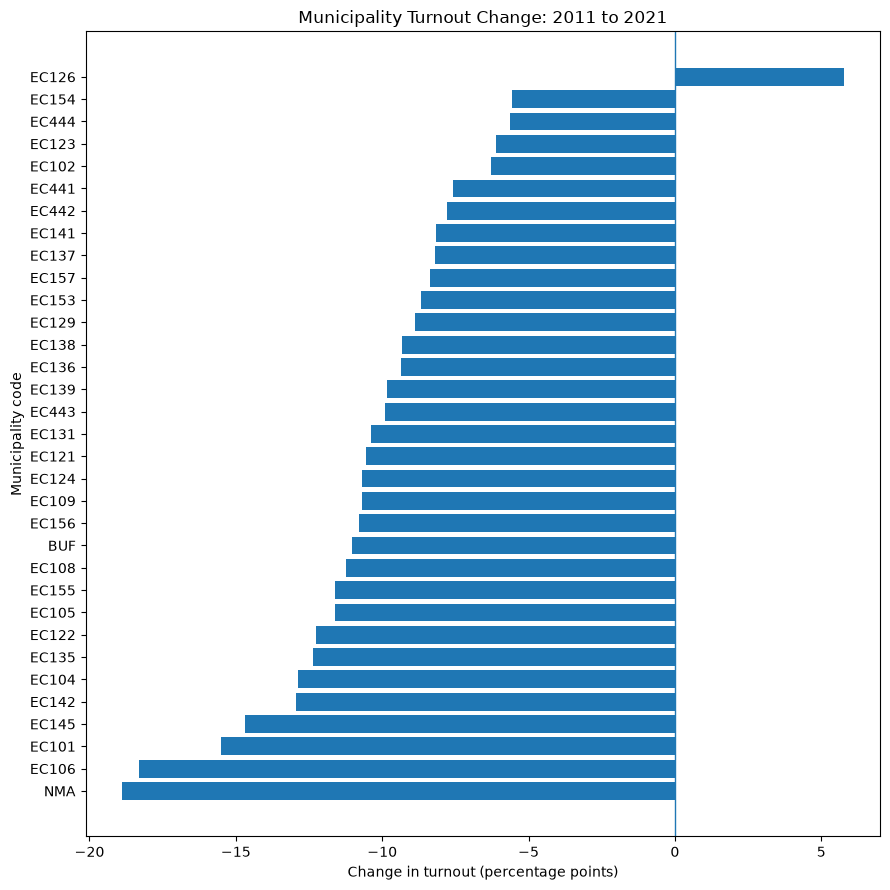

In [8]:
fig, ax = plt.subplots(figsize=(9, 9))
plot_change = turnout_change.sort_values("Change_2011_2021_pts")
ax.barh(plot_change["MuniCode"], plot_change["Change_2011_2021_pts"])
ax.axvline(0, linewidth=1)
ax.set_title("Municipality Turnout Change: 2011 to 2021")
ax.set_xlabel("Change in turnout (percentage points)")
ax.set_ylabel("Municipality code")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "turnout_change_2011_2021.png", dpi=180, bbox_inches="tight")
plt.show()


## 6. Political competition and turnout

Phase 1 already calculated:

- **ENP** — Effective Number of Parties, from the full party vote distribution.
- **Margin_pts** — percentage-point gap between the first- and second-placed party.
- **NumberOfParties** — number of parties represented in the municipal PR vote data.

These same-election variables are appropriate here for **descriptive association analysis**.

They must **not** later be used as pre-election predictors of turnout for that same election because they are only observed after votes are counted. Phase 4 will use lagged competition variables instead.


In [9]:
competition_vars = ["Turnout_%", "ENP", "Margin_pts", "NumberOfParties"]
competition_corr = master[competition_vars].corr()

display(competition_corr.round(3))


,Turnout_%,ENP,Margin_pts,NumberOfParties
Turnout_%,1.000,-0.205,-0.066,-0.432
ENP,-0.205,1.000,-0.879,0.411
Margin_pts,-0.066,-0.879,1.000,-0.137
NumberOfParties,-0.432,0.411,-0.137,1.000


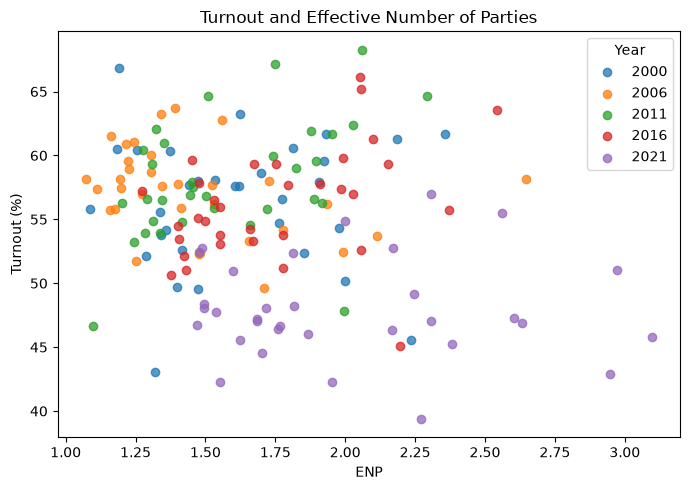

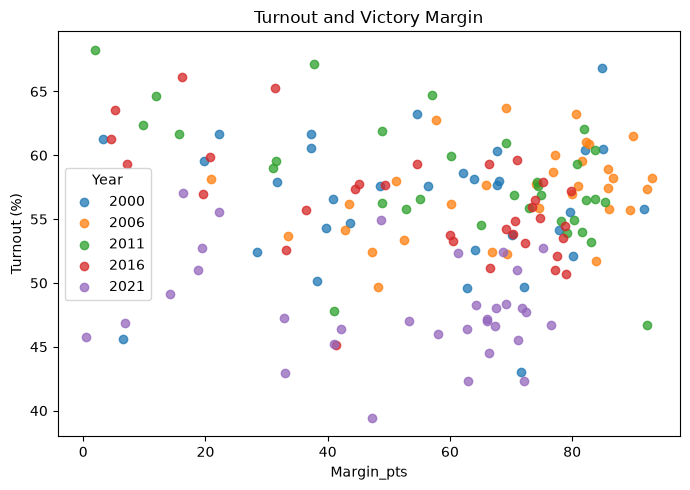

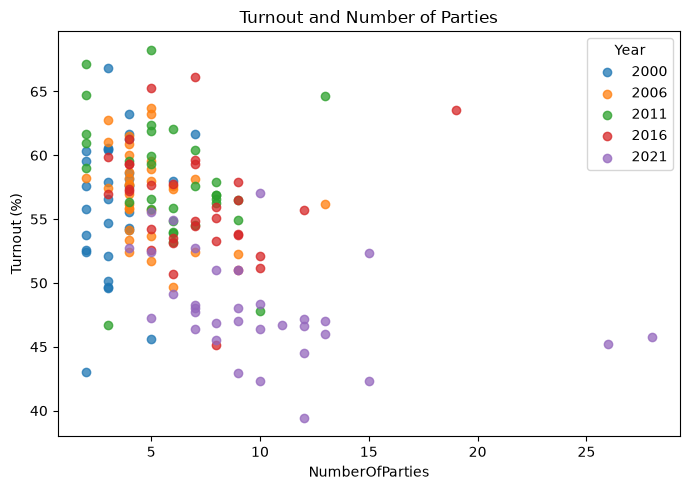

In [10]:
for x, title, filename in [
    ("ENP", "Turnout and Effective Number of Parties", "turnout_vs_enp.png"),
    ("Margin_pts", "Turnout and Victory Margin", "turnout_vs_margin.png"),
    ("NumberOfParties", "Turnout and Number of Parties", "turnout_vs_number_of_parties.png"),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    for year, group in master.groupby("Year"):
        ax.scatter(group[x], group["Turnout_%"], label=str(year), alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel("Turnout (%)")
    ax.legend(title="Year")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


## 7. Demographic associations with turnout

Demographic analysis is restricted to **2011–2021**, where Phase 2 provides municipality features.

Remember:

- 2011 values are observed Census values.
- 2016 and 2021 values are interpolated between the 2011 and 2022 municipality snapshots.
- These are municipality-level characteristics, not individual voter attributes.


In [11]:
analysis_2011_2021 = master[master["Year"].isin([2011, 2016, 2021])].copy()

demographic_vars = [
    "Pop", "U15", "O65", "Med", "NoSch",
    "Matric", "Higher", "Formal", "Water", "Elec"
]

demo_corr = (
    analysis_2011_2021[["Turnout_%"] + demographic_vars]
    .corr()["Turnout_%"]
    .drop("Turnout_%")
    .sort_values()
    .rename("CorrelationWithTurnout")
    .reset_index()
    .rename(columns={"index": "Variable"})
)

display(demo_corr.round(3))


,Variable,CorrelationWithTurnout
0,Elec,-0.196
1,Matric,-0.147
2,Pop,-0.134
3,U15,-0.127
4,Higher,-0.063
5,Formal,-0.001
6,NoSch,0.003
7,O65,0.057
8,Med,0.061
9,Water,0.178


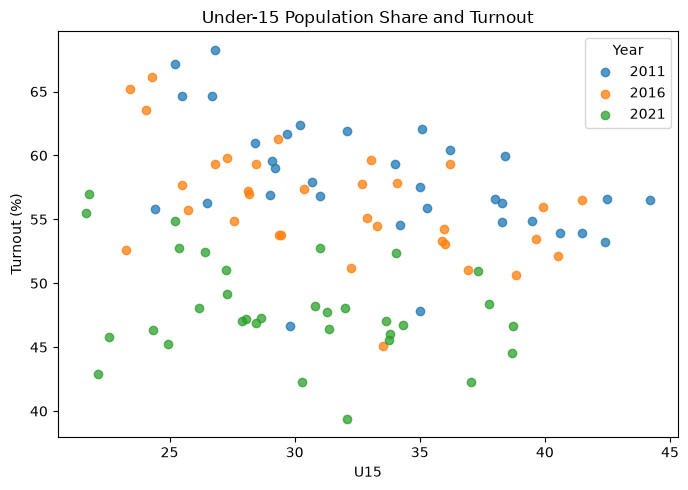

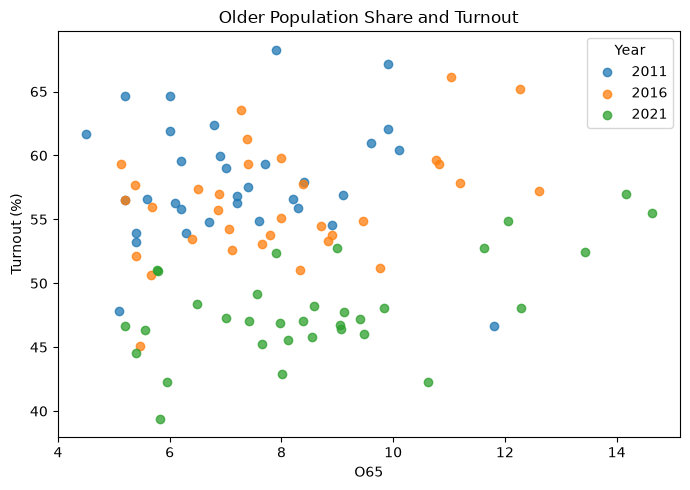

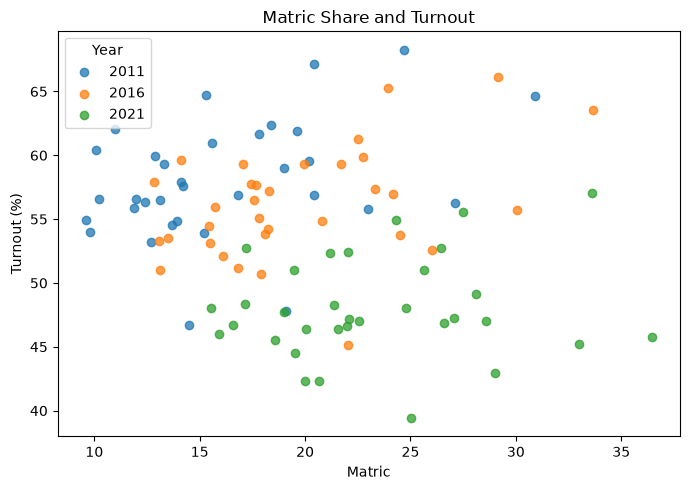

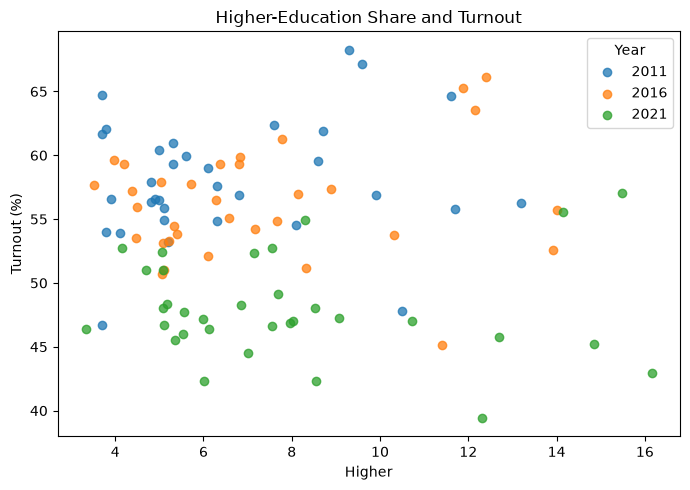

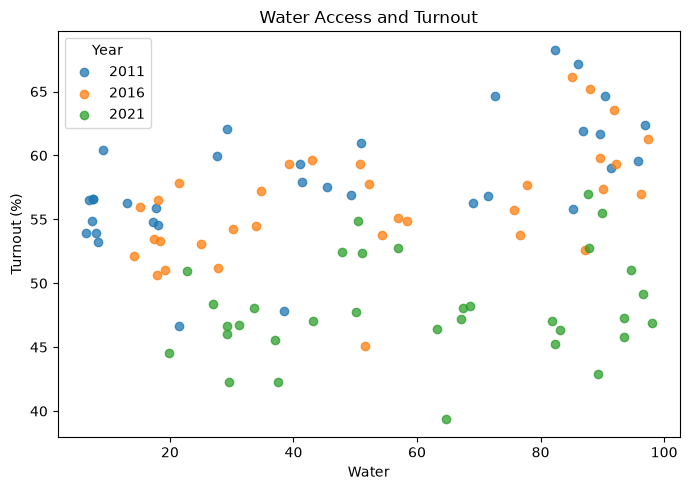

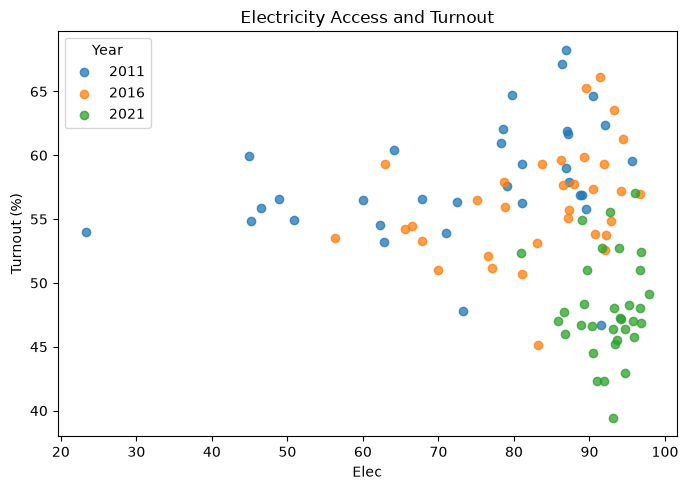

In [12]:
for x, title, filename in [
    ("U15", "Under-15 Population Share and Turnout", "turnout_vs_u15.png"),
    ("O65", "Older Population Share and Turnout", "turnout_vs_o65.png"),
    ("Matric", "Matric Share and Turnout", "turnout_vs_matric.png"),
    ("Higher", "Higher-Education Share and Turnout", "turnout_vs_higher_education.png"),
    ("Water", "Water Access and Turnout", "turnout_vs_water.png"),
    ("Elec", "Electricity Access and Turnout", "turnout_vs_electricity.png"),
]:
    fig, ax = plt.subplots(figsize=(7, 5))
    for year, group in analysis_2011_2021.groupby("Year"):
        ax.scatter(group[x], group["Turnout_%"], label=str(year), alpha=0.75)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel("Turnout (%)")
    ax.legend(title="Year")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


## 8. Combined association table

In [13]:
association_vars = demographic_vars + ["ENP", "Margin_pts", "NumberOfParties"]

association_table = (
    analysis_2011_2021[["Turnout_%"] + association_vars]
    .corr()["Turnout_%"]
    .drop("Turnout_%")
    .sort_values()
    .rename("PearsonCorrelationWithTurnout")
    .reset_index()
    .rename(columns={"index": "Variable"})
)

display(association_table.round(3))


,Variable,PearsonCorrelationWithTurnout
0,NumberOfParties,-0.459
1,Margin_pts,-0.217
2,Elec,-0.196
3,ENP,-0.150
4,Matric,-0.147
5,Pop,-0.134
6,U15,-0.127
7,Higher,-0.063
8,Formal,-0.001
9,NoSch,0.003


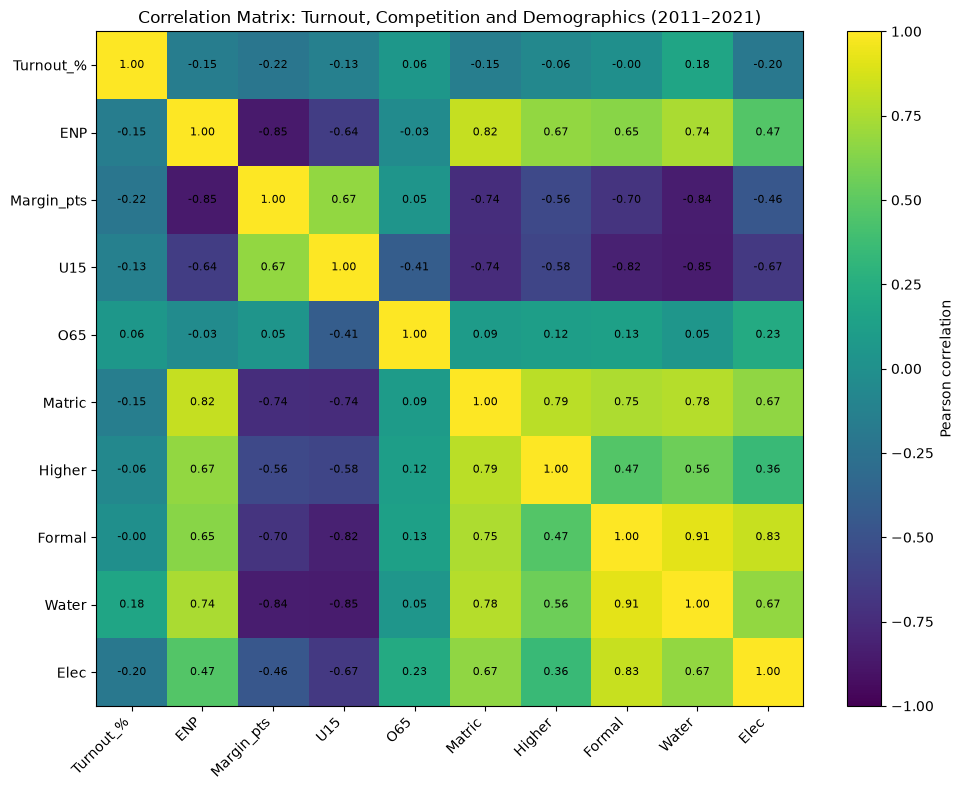

In [14]:
corr_vars = ["Turnout_%", "ENP", "Margin_pts", "U15", "O65", "Matric", "Higher", "Formal", "Water", "Elec"]
corr_matrix = analysis_2011_2021[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_vars)))
ax.set_yticks(range(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix: Turnout, Competition and Demographics (2011–2021)")
fig.colorbar(im, ax=ax, label="Pearson correlation")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "turnout_correlation_matrix.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Leakage-safe Phase 4 modelling view

Phase 4 will predict turnout using information that could plausibly be known before the target election.

Therefore this view retains:

- previous turnout;
- previous ENP;
- previous victory margin;
- previous registered voters;
- contemporaneous demographic estimates aligned by Phase 2.

It deliberately excludes same-election `ENP`, `Margin_pts`, `TopShare_%`, party shares and other election outcomes from the predictor set.

For the historical 2021 backtest, 2011 and 2016 can form training observations and 2021 can be held out for testing.


In [15]:
model_feature_cols = [
    "MuniCode", "Year", "Turnout_%",
    "PreviousRegisteredVoters", "PreviousTurnout_%",
    "PreviousENP", "PreviousMargin_pts", "PreviousTopShare_%",
    "Pop", "U15", "O65", "Med", "NoSch",
    "Matric", "Higher", "Formal", "Water", "Elec",
    "DemographicStatus"
]

model_ready = master.loc[
    master["Year"].isin([2011, 2016, 2021]),
    model_feature_cols
].copy()

assert len(model_ready) == 99
assert model_ready[["PreviousTurnout_%", "PreviousENP", "PreviousMargin_pts"]].notna().all().all()
assert model_ready[demo_cols].notna().all().all()

print("Model-ready rows:", len(model_ready))
print("Training years:", [2011, 2016])
print("Historical holdout year:", 2021)
display(model_ready.head())


Model-ready rows: 99
Training years: [2011, 2016]
Historical holdout year: 2021


,MuniCode,Year,Turnout_%,PreviousRegisteredVoters,PreviousTurnout_%,PreviousENP,PreviousMargin_pts,PreviousTopShare_%,Pop,U15,O65,Med,NoSch,Matric,Higher,Formal,Water,Elec,DemographicStatus
65,BUF,2011,56.261464,358460.0,52.260782,1.477063,69.401808,81.334215,781853.0,26.5,6.1,27.0,5.1,27.1,13.2,71.9,69.1,81.1,Observed
66,EC101,2011,62.354111,34211.0,53.669872,2.112625,33.518313,62.280799,79292.0,30.2,6.8,26.0,9.3,18.4,7.6,95.3,96.9,92.1,Observed
67,EC102,2011,59.039597,17453.0,53.326076,1.657324,52.410167,74.441280,36002.0,29.2,7.0,27.0,10.5,19.0,6.1,95.9,91.4,86.9,Observed
68,EC104,2011,55.798199,43059.0,52.397873,1.482204,66.942707,80.908232,80390.0,24.4,6.2,26.0,6.3,23.0,11.7,85.4,85.2,89.5,Observed
69,EC105,2011,67.149268,29895.0,62.759659,1.557806,57.749744,77.583697,61176.0,25.2,9.9,25.0,9.7,20.4,9.6,83.6,86.0,86.3,Observed


## 10. Save Phase 3 outputs

The master panel is the authoritative integrated dataset for downstream work. The old prototype `data/processed/panels/panel.csv` should no longer be treated as the modelling source.


In [16]:
outputs = {
    "master_panel_2000_2021.csv": master,
    "analysis_panel_2011_2021.csv": analysis_2011_2021,
    "turnout_model_ready_2011_2021.csv": model_ready,
    "turnout_summary_by_year.csv": turnout_summary,
    "municipality_turnout_change_2011_2021.csv": turnout_change,
    "turnout_association_table_2011_2021.csv": association_table,
    "phase3_quality_control.csv": qc,
}

for filename, frame in outputs.items():
    path = PANEL_DIR / filename
    frame.to_csv(path, index=False)
    print("Saved:", path.relative_to(PROJECT_ROOT), "|", len(frame), "rows")

print("\nFigures saved to:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Phase 3 complete.")


Saved: data\processed\panels\phase3\master_panel_2000_2021.csv | 164 rows
Saved: data\processed\panels\phase3\analysis_panel_2011_2021.csv | 99 rows
Saved: data\processed\panels\phase3\turnout_model_ready_2011_2021.csv | 99 rows
Saved: data\processed\panels\phase3\turnout_summary_by_year.csv | 5 rows
Saved: data\processed\panels\phase3\municipality_turnout_change_2011_2021.csv | 33 rows
Saved: data\processed\panels\phase3\turnout_association_table_2011_2021.csv | 13 rows
Saved: data\processed\panels\phase3\phase3_quality_control.csv | 13 rows

Figures saved to: reports\figures\phase3
Phase 3 complete.


## Phase 3 completion note

Phase 3 has now:

- integrated Phase 1 and Phase 2;
- preserved the complete 2000–2021 electoral history;
- created the 2011–2021 demographic analysis subset;
- produced turnout, competition and demographic EDA;
- retained the teammate's useful turnout-analysis objectives;
- prevented same-election competition measures from leaking into the future turnout model;
- prepared the 99-row historical modelling dataset for Phase 4.

### Next phase

**Phase 4 — Turnout Model**

The central historical evaluation will hold out **2021** and compare the model against simple baselines before any 2026 scenario is produced.


## Submission interpretation

Phase 3 joins elections, party support and temporally aligned demographic context into one municipality-election analytical panel. Descriptive relationships involving same-election ENP, margin and demographics are used for EDA only. A separate leakage-safe turnout modelling view contains only information that can be justified as available before the target election.

**Caution:** municipality-level associations do not establish individual voter behaviour or causal effects.